# Метод опорных векторов

This notebook contains an excerpt from the Python Data Science Handbook by Jake VanderPlas; the content is available on [GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).

Метод опорных векторов (SVM) — это особенно мощный и гибкий класс алгоритмов обучения с учителем, применимый как для задач классификации, так и для регрессии.
В этом разделе мы разовьём интуицию, стоящую за методом опорных векторов, и рассмотрим его применение в задачах классификации.

Начнём со стандартных импортов:

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import seaborn as sns; sns.set_theme()

В качестве примера рассмотрим простую задачу классификации, в которой два класса точек хорошо разделены:

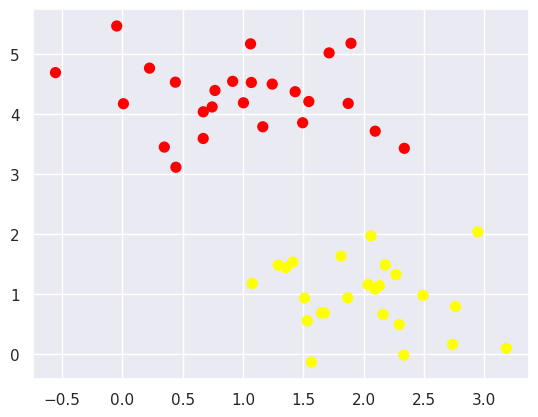

In [6]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

Линейный классификатор попытается провести прямую линию, разделяющую два множества данных, и тем самым создать модель для классификации.
Для двумерных данных, подобных показанным здесь, это задача, которую мы могли бы решить вручную.
Но тут же мы видим проблему: существует более одной разделяющей линии, которая идеально различает два класса!

Мы можем нарисовать их следующим образом:

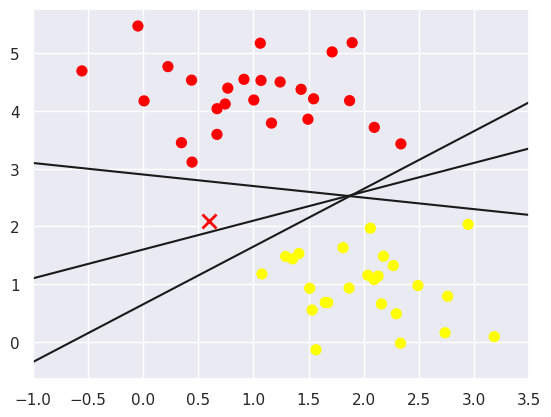

In [7]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

Это три *очень* разных разделителя, которые тем не менее идеально различают эти выборки.
В зависимости от того, какой из них вы выберете, новая точка данных (например, отмеченная символом «X» на графике) получит разную метку!
Очевидно, что простая интуиция «провести линию между классами» недостаточна, и нам нужно подумать глубже.

## Метод опорных векторов: максимизация *отступа*

Метод опорных векторов предлагает один из способов улучшить ситуацию.
Интуиция такова: вместо того чтобы просто проводить линию нулевой ширины между классами, мы можем провести вокруг каждой линии *отступ* (margin) некоторой ширины — до ближайшей точки.
Вот пример того, как это может выглядеть:

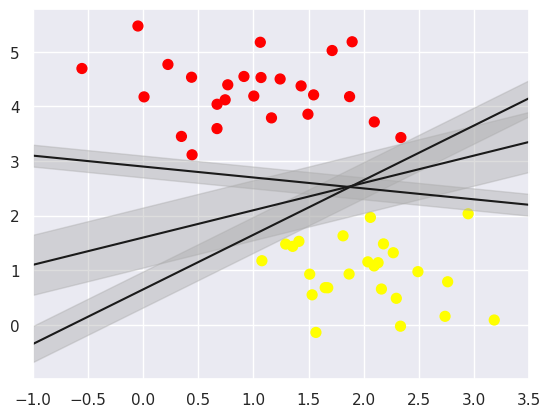

In [8]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

В методе опорных векторов линия, максимизирующая этот отступ, выбирается в качестве оптимальной модели.
Метод опорных векторов является примером оценки с *максимальным отступом* (maximum margin estimator).

### Обучение метода опорных векторов

Посмотрим на результат обучения на этих данных: мы воспользуемся классификатором опорных векторов из Scikit-Learn для обучения модели SVM.
Пока что мы используем линейное ядро и зададим параметр ``C`` очень большим числом (значение этих параметров мы обсудим чуть позже).

In [9]:
from sklearn.svm import SVC 
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

,C,10000000000.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Для лучшей визуализации происходящего создадим вспомогательную функцию, которая будет отображать решающие границы SVM:

In [22]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none',
                   edgecolors='black');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

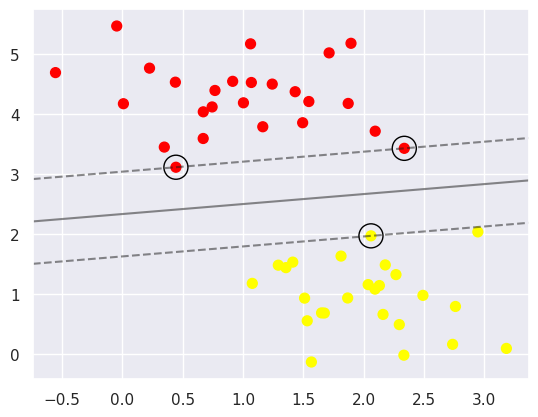

In [23]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model);

Это разделяющая линия, которая максимизирует отступ между двумя множествами точек.
Обратите внимание, что несколько обучающих точек касаются границы отступа: на рисунке они обозначены чёрными кружками.
Эти точки являются ключевыми элементами модели и называются *опорными векторами* — именно они дали алгоритму его название.
В Scikit-Learn идентификаторы этих точек хранятся в атрибуте классификатора ``support_vectors_``:

In [24]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

Ключ к успеху этого классификатора в том, что при обучении имеет значение только положение опорных векторов; любые точки, расположенные дальше от границы отступа на правильной стороне, не влияют на модель!
Технически это объясняется тем, что эти точки не вносят вклада в функцию потерь, используемую для обучения модели, поэтому их положение и количество не имеют значения, пока они не пересекают границу отступа.

Мы можем убедиться в этом, например, построив модель, обученную на первых 60 и первых 120 точках набора данных:

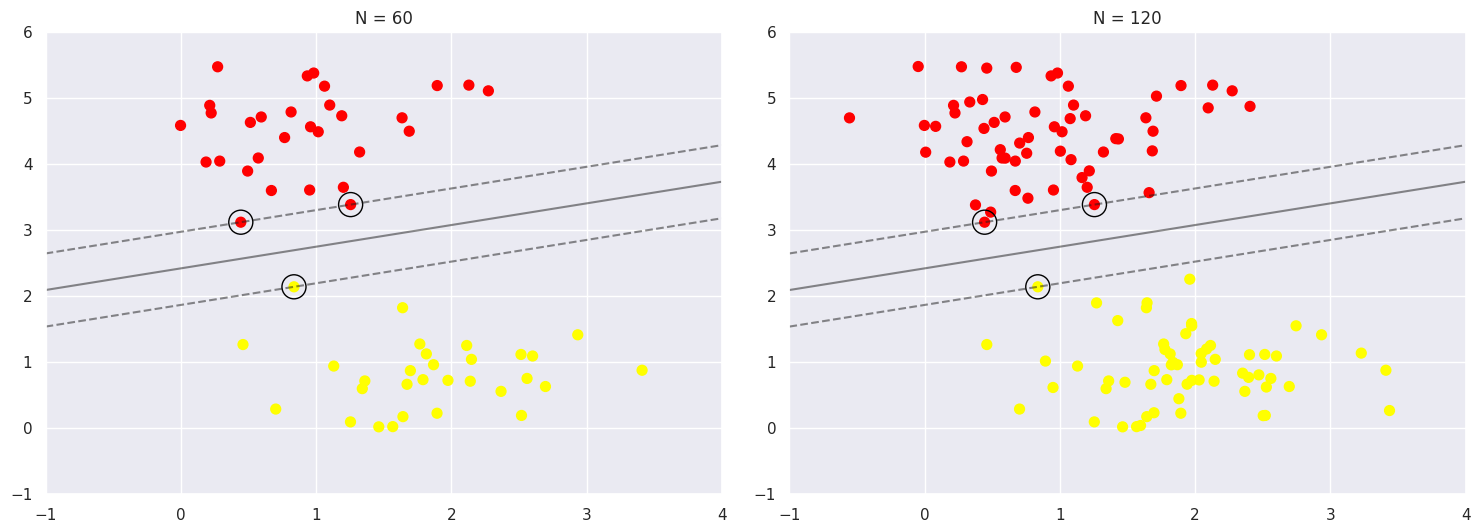

In [26]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

Слева мы видим модель и опорные векторы для 60 обучающих точек.
Справа мы удвоили количество обучающих точек, но модель не изменилась: три опорных вектора с левой панели остались опорными векторами и на правой панели.
Эта нечувствительность к точному поведению удалённых точек — одна из сильных сторон модели SVM.

interactive(children=(Dropdown(description='N', options=(10, 200), value=10), Output()), _dom_classes=('widget…

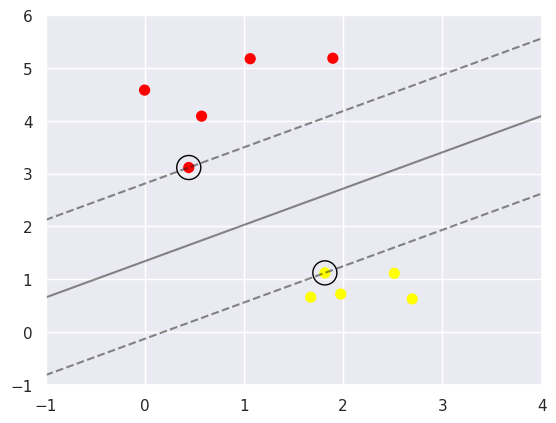

In [29]:
from ipywidgets import interact, fixed
interact(plot_svm, N=[10, 200], ax=fixed(None));

### За пределами линейных границ: ядерный SVM

SVM становится чрезвычайно мощным инструментом в сочетании с *ядрами* (kernels), чтобы спроецировать данные в пространство более высокой размерности.

Чтобы мотивировать необходимость ядер, рассмотрим данные, которые не являются линейно разделимыми:

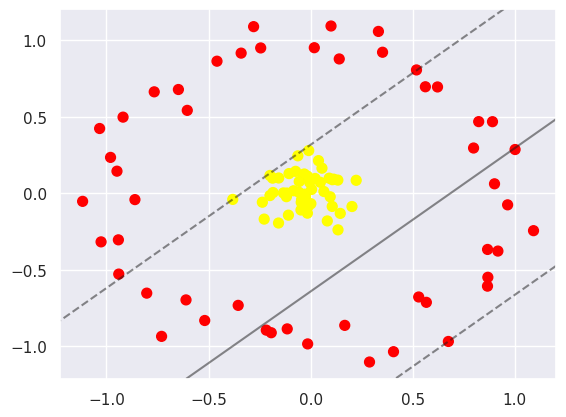

In [30]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

Очевидно, что никакое линейное разделение *никогда* не сможет разделить эти данные.
Но мы можем спроецировать данные в пространство более высокой размерности, где линейный разделитель *был бы* достаточен.
Например, одной простой проекцией может быть вычисление *радиальной базисной функции*, центрированной на среднем скоплении:

In [31]:
r = np.exp(-(X ** 2).sum(1))

Мы можем визуализировать это дополнительное измерение данных с помощью трёхмерного графика — если вы запускаете этот ноутбук интерактивно, вы сможете вращать график с помощью ползунков:

In [38]:
import plotly.express as px

fig = px.scatter_3d(
    x=X[:, 0], y=X[:, 1], z=r,
    color=y.astype(str),
    color_discrete_sequence=["yellow", "red"],
    labels={"x": "x", "y": "y", "z": "r", "color": "class"},
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(width=700, height=600)
fig.show()

Мы видим, что с этим дополнительным измерением данные становятся тривиально линейно разделимыми — достаточно провести разделяющую плоскость, скажем, при *r*=0.7.

Здесь нам пришлось выбрать и тщательно настроить проекцию: если бы мы не центрировали нашу радиальную базисную функцию в правильном месте, мы не получили бы таких чистых, линейно разделимых результатов.
В общем случае необходимость делать такой выбор — это проблема: мы хотели бы как-то автоматически находить лучшие базисные функции.

Одна из стратегий — вычислить базисную функцию с центром в *каждой* точке набора данных и позволить алгоритму SVM отсеять результаты.
Такой тип преобразования с помощью базисных функций называется *ядерным преобразованием* (kernel transformation), поскольку он основан на отношении сходства (или ядре) между каждой парой точек.

Потенциальная проблема этой стратегии — проецирование $N$ точек в $N$ измерений — в том, что вычисления могут стать очень затратными при росте $N$.
Однако благодаря изящной процедуре, известной как [*ядерный трюк*](https://education.yandex.ru/handbook/math/article/svm-i-yadrovoi-triuk) (kernel trick), обучение на ядерно-преобразованных данных может быть выполнено неявно — без построения полного $N$-мерного представления ядерной проекции!

В Scikit-Learn мы можем применить ядерный SVM, просто заменив линейное ядро на RBF-ядро (ядро радиальной базисной функции), используя гиперпараметр модели ``kernel``:

In [48]:
clf = SVC(kernel='rbf', C=1e6)
clf.fit(X, y)

,C,1000000.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [49]:
import plotly.graph_objects as go

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx = np.linspace(x_min, x_max, 120)
yy = np.linspace(y_min, y_max, 120)
XX, YY = np.meshgrid(xx, yy)
Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
Z = np.clip(Z, -3, 3)

point_z = np.clip(clf.decision_function(X), -3, 3)
sv_z = np.clip(clf.decision_function(clf.support_vectors_), -3, 3)

fig = go.Figure()

fig.add_trace(go.Surface(
    x=xx, y=yy, z=Z,
    colorscale="RdYlGn", opacity=0.6,
    showscale=True,
    colorbar=dict(title="decision<br>function"),
    name="decision surface",
))

for level, label in [
    (0, "decision boundary (z=0)"),
    (1, "margin (z=+1)"),
    (-1, "margin (z=-1)"),
]:
    fig.add_trace(go.Surface(
        x=xx, y=yy,
        z=np.full_like(Z, level),
        colorscale=[[0, "gray"], [1, "gray"]],
        opacity=0.15, showscale=False,
        name=label,
    ))

for cls, color, label in [(0, "red", "class 0"), (1, "orange", "class 1")]:
    mask = y == cls
    fig.add_trace(go.Scatter3d(
        x=X[mask, 0], y=X[mask, 1], z=point_z[mask],
        mode="markers",
        marker=dict(size=5, color=color),
        name=label,
    ))

fig.add_trace(go.Scatter3d(
    x=clf.support_vectors_[:, 0],
    y=clf.support_vectors_[:, 1],
    z=sv_z,
    mode="markers",
    marker=dict(
        size=8, color="rgba(0,0,0,0)",
        line=dict(color="black", width=3),
    ),
    name="support vectors",
))

fig.update_layout(
    width=900, height=600,
    template="plotly_white",
    scene=dict(
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="decision function",
    ),
)
fig.show()

С помощью этого ядерного метода опорных векторов мы находим подходящую нелинейную решающую границу.
Стратегия ядерного преобразования часто используется в машинном обучении для превращения быстрых линейных методов в быстрые нелинейные, особенно для моделей, в которых может быть применён ядерный трюк.

### Настройка SVM: смягчение отступов

До сих пор наше обсуждение касалось очень «чистых» наборов данных, в которых существует идеальная решающая граница.
Но что, если в ваших данных есть некоторое перекрытие классов?
Например, у вас могут быть такие данные:

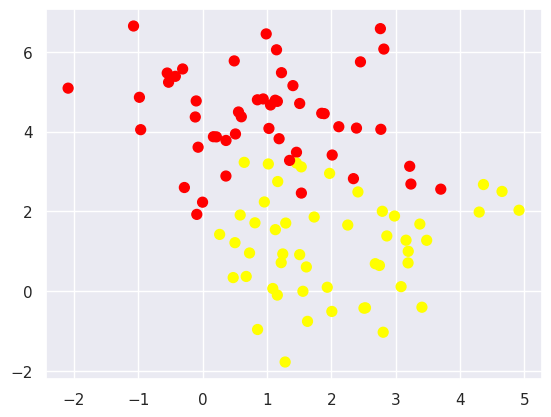

In [50]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

Для обработки этого случая в реализации SVM есть параметр, который «смягчает» отступ: он позволяет некоторым точкам проникать в область отступа, если это приводит к лучшей модели.
Жёсткость отступа контролируется параметром настройки, обычно обозначаемым $C$.
При очень большом $C$ отступ жёсткий, и точки не могут находиться внутри него.
При меньшем $C$ отступ мягче и может расширяться, включая некоторые точки.
Вспомним:

$$
\begin{align*}
\min_{\mathbf{w},b,\{\xi_i\}} \quad & \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^N \xi_i \\
\text{при условиях:}\quad & y_i (\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i,\quad \xi_i \geq 0, \quad i=1,\ldots,N
\end{align*}
$$

Здесь $\mathbf{w}$ и $b$ — параметры гиперплоскости, $\xi_i$ — переменные для штрафа за ошибки, $C > 0$ — параметр регуляризации, контролирующий жёсткость отступа.

На графике ниже показано, как изменение параметра $C$ влияет на итоговую модель через смягчение отступа:

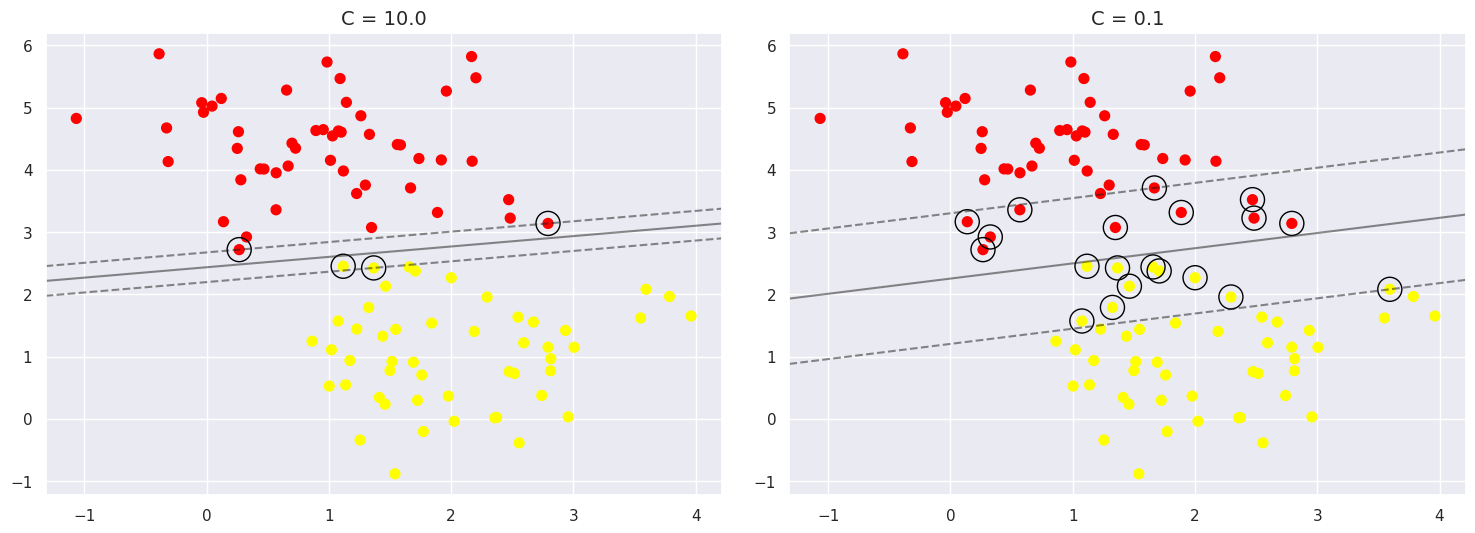

In [51]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

Оптимальное значение параметра $C$ зависит от вашего набора данных и должно подбираться с помощью кросс-валидации или аналогичной процедуры.

## Пример: распознавание лиц

В качестве примера применения метода опорных векторов рассмотрим задачу распознавания лиц.
Мы будем использовать набор данных Labeled Faces in the Wild, который содержит несколько тысяч фотографий различных публичных персон.
Загрузчик этого набора данных встроен в Scikit-Learn:

In [52]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Построим несколько лиц, чтобы увидеть, с чем мы работаем:

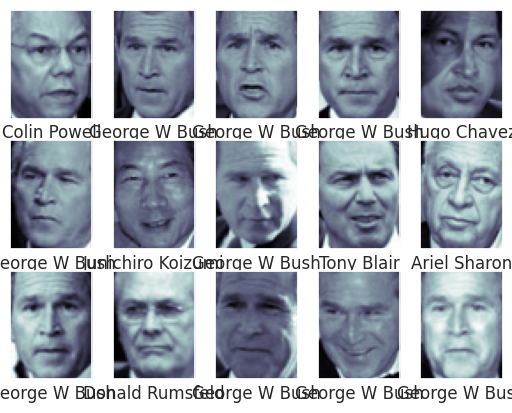

In [53]:
fig, ax = plt.subplots(3, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

Каждое изображение содержит [62×47] или почти 3000 пикселей.
Мы могли бы просто использовать значение каждого пикселя как признак, но часто эффективнее применить предварительную обработку для извлечения более содержательных признаков; здесь мы используем метод главных компонент (PCA) для извлечения 150 фундаментальных компонент, которые подадим в классификатор опорных векторов.
Проще всего это сделать, объединив препроцессор и классификатор в единый конвейер (pipeline):

In [56]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pca = PCA(n_components=150, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

Для тестирования нашего классификатора разделим данные на обучающую и тестовую выборки:

In [57]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                random_state=42)

Наконец, мы можем использовать поиск по сетке с кросс-валидацией для перебора гиперпараметров.
Здесь мы будем настраивать ``C`` (контролирует жёсткость отступа) и ``gamma`` (контролирует размер ядра радиальной базисной функции) и определим лучшую модель:

In [58]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: user 13min 15s, sys: 1.39 s, total: 13min 16s
Wall time: 1min 15s
{'svc__C': 5, 'svc__gamma': 0.001}


Оптимальные значения оказались ближе к середине нашей сетки; если бы они оказались на краях, нам следовало бы расширить сетку, чтобы убедиться, что мы нашли истинный оптимум.

Теперь с этой моделью, прошедшей кросс-валидацию, мы можем предсказать метки для тестовых данных, которые модель ещё не видела:

In [59]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

Посмотрим на несколько тестовых изображений вместе с их предсказанными значениями:

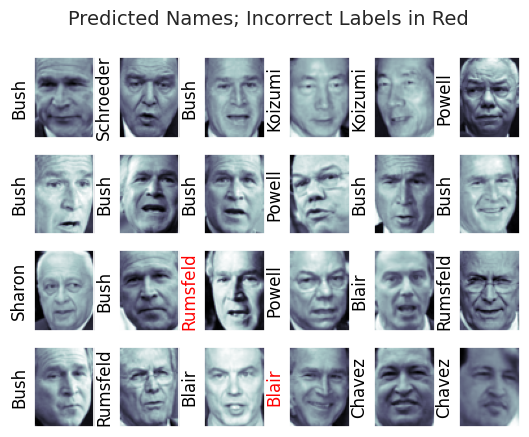

In [60]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

В этой небольшой выборке наш оптимальный классификатор неправильно определил только только 2 лица.
Мы можем получить более полное представление о качестве нашего классификатора с помощью отчёта о классификации (classification report), в котором приводится статистика для каждой метки:

In [61]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



Мы также можем отобразить матрицу ошибок (confusion matrix) для этих классов:

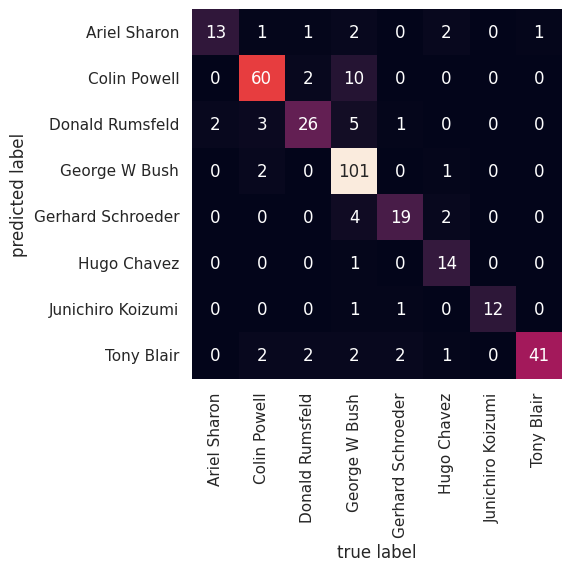

In [62]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

Это помогает нам понять, какие метки классификатор чаще всего путает.

В реальной задаче распознавания лиц, где фотографии не предоставляются предварительно обрезанными в аккуратные ячейки, единственное отличие в схеме классификации лиц — это выбор признаков: потребуется более сложный алгоритм для нахождения лиц и извлечения признаков, не зависящих от пикселизации.
Для такого рода приложений хорошим вариантом является использование [OpenCV](http://opencv.org), которая, помимо прочего, включает предобученные реализации современных инструментов извлечения признаков для изображений в целом и лиц в частности.